In [ ]:
from google.colab import files

uploaded = files.upload()

Saving cleaned_titanic.csv to cleaned_titanic.csv


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("cleaned_titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


**Hypothesis**

H₀ (Null Hypothesis):
Passenger gender and survival are independent.

H₁ (Alternative Hypothesis):
Passenger gender and survival are associated.

In [ ]:
contingency_table = pd.crosstab(df["Sex"], df["Survived"])

contingency_table

Survived,0,1
Sex,,
female,81,233
male,468,109


In [ ]:
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2)

print("P-value:", p)

print("Degrees of Freedom:", dof)

Chi-Square Statistic: 260.71702016732104
P-value: 1.1973570627755645e-58
Degrees of Freedom: 1


In [ ]:
alpha = 0.05

if p < alpha:
    print("Reject the Null Hypothesis")

    print("There is a significant relationship between Gender and Survival.")

else:
    print("Fail to Reject the Null Hypothesis")

    print("There is no significant relationship.")

Reject the Null Hypothesis
There is a significant relationship between Gender and Survival.


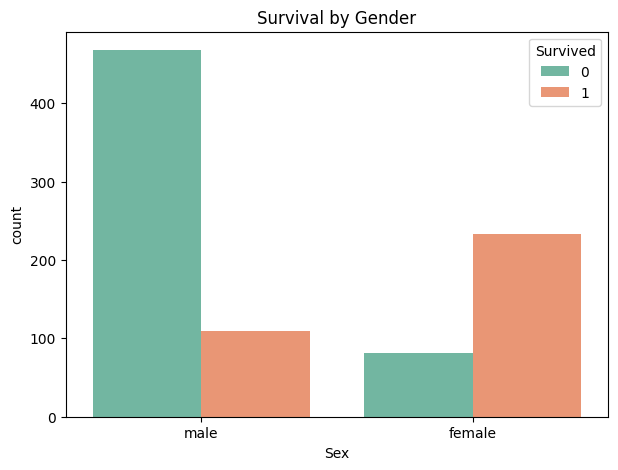

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Sex",
    hue="Survived",
    data=df,
    palette="Set2"
)

plt.title("Survival by Gender")

plt.show()

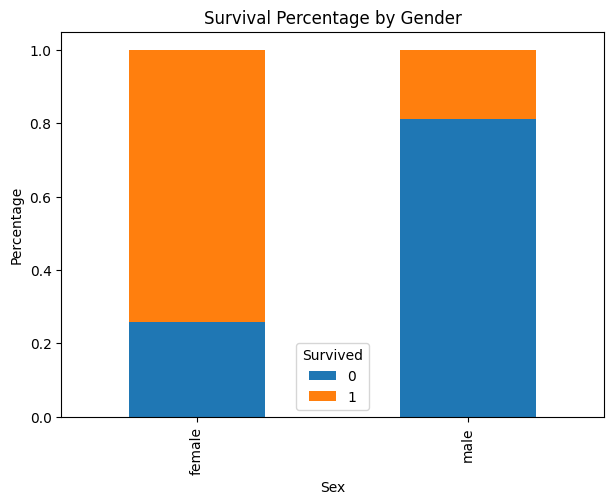

In [ ]:
survival_rate = pd.crosstab(df["Sex"], df["Survived"], normalize="index")

survival_rate.plot(
    kind="bar",
    stacked=True,
    figsize=(7,5)
)

plt.title("Survival Percentage by Gender")

plt.ylabel("Percentage")

plt.show()

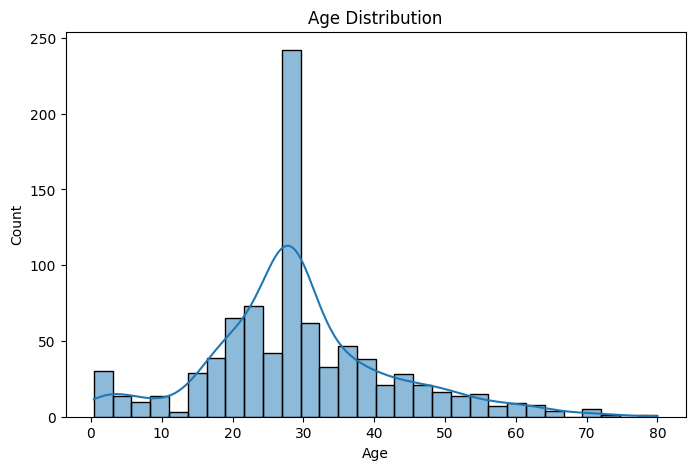

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution")

plt.show()

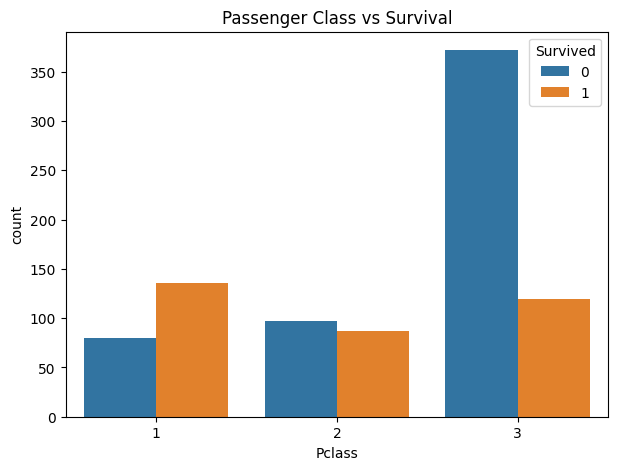

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Pclass",
    hue="Survived",
    data=df
)

plt.title("Passenger Class vs Survival")

plt.show()

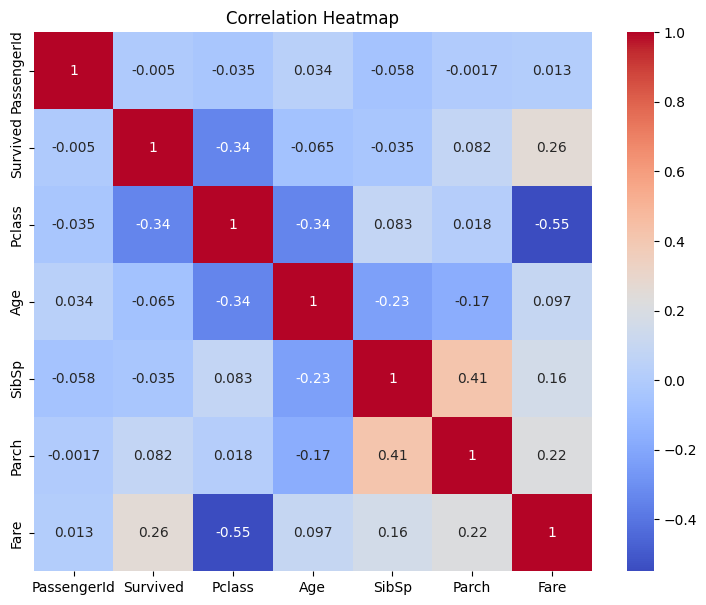

In [ ]:
plt.figure(figsize=(9,7))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

**conclusion**

The Chi-Square test produced a p-value less than 0.05, indicating a statistically significant relationship between passenger gender and survival. Therefore, the null hypothesis was rejected, supporting the conclusion that gender influenced survival outcomes on the Titanic.